In [2]:
import requests

url = "https://power.larc.nasa.gov/api/temporal/daily/point"

params = {
    "parameters": "PRECTOTCORR,GWETROOT",
    "community": "AG",
    "longitude": 34.75,
    "latitude": 0.28,
    "start": "20220301",
    "end": "20220430",
    "format": "JSON"
}

response = requests.get(url, params=params, timeout=15)

print("Status code:", response.status_code)
print("Success!" if response.status_code == 200 else "Something went wrong")


Status code: 200
Success!


In [3]:
data = response.json()

parameters = data["properties"]["parameter"]

rainfall_raw = parameters["PRECTOTCORR"]
soil_raw = parameters["GWETROOT"]

print("=== RAINFALL (PRECTOTCORR) - First 5 days ===")
items = list(rainfall_raw.items())
for date, value in items[:5]:
    print(f"  {date}: {value} mm")

print()
print("=== SOIL MOISTURE (GWETROOT) - First 5 days ===")
items = list(soil_raw.items())
for date, value in items[:5]:
    print(f"  {date}: {value} (fraction)")

=== RAINFALL (PRECTOTCORR) - First 5 days ===
  20220301: 0.02 mm
  20220302: 1.63 mm
  20220303: 0.24 mm
  20220304: 0.31 mm
  20220305: 0.05 mm

=== SOIL MOISTURE (GWETROOT) - First 5 days ===
  20220301: 0.54 (fraction)
  20220302: 0.54 (fraction)
  20220303: 0.54 (fraction)
  20220304: 0.53 (fraction)
  20220305: 0.53 (fraction)


In [4]:
import pandas as pd

rainfall = pd.Series(rainfall_raw)
rainfall.index = pd.to_datetime(rainfall.index, format="%Y%m%d")
rainfall = rainfall.replace(-999.0, 0.0)

soil = pd.Series(soil_raw)
soil.index = pd.to_datetime(soil.index, format="%Y%m%d")
soil = soil.replace(-999.0, float('nan'))

df = pd.DataFrame({
    "rainfall_mm": rainfall,
    "soil_moisture": soil
})

print(df.head(10))
print()
print(f"Total days of data: {len(df)}")
print(f"Date range: {df.index[0].date()} to {df.index[-1].date()}")
print(f"Total rainfall: {df['rainfall_mm'].sum():.1f} mm")
print(f"Max single-day rain: {df['rainfall_mm'].max():.1f} mm")
print(f"Average soil moisture: {df['soil_moisture'].mean():.3f}")

            rainfall_mm  soil_moisture
2022-03-01         0.02           0.54
2022-03-02         1.63           0.54
2022-03-03         0.24           0.54
2022-03-04         0.31           0.53
2022-03-05         0.05           0.53
2022-03-06         2.07           0.52
2022-03-07         0.36           0.52
2022-03-08         0.91           0.52
2022-03-09         0.05           0.52
2022-03-10         0.04           0.51

Total days of data: 61
Date range: 2022-03-01 to 2022-04-30
Total rainfall: 234.3 mm
Max single-day rain: 25.7 mm
Average soil moisture: 0.525


In [5]:
# Find the biggest rain day
biggest_rain_day = df["rainfall_mm"].idxmax()
biggest_rain_value = df["rainfall_mm"].max()

print(f"Biggest rain day: {biggest_rain_day.date()} with {biggest_rain_value}mm")
print()

# Show 5 days before and 15 days after that event
window_start = biggest_rain_day - pd.Timedelta(days=5)
window_end = biggest_rain_day + pd.Timedelta(days=15)

surrounding = df[window_start:window_end]
print("=== RAINFALL AROUND THE BIG EVENT ===")
for date, row in surrounding.iterrows():
    rain = row["rainfall_mm"]
    bar = "█" * int(rain)
    marker = " ← BIG DAY" if date == biggest_rain_day else ""
    print(f"  {date.date()}: {rain:5.2f}mm  {bar}{marker}")

Biggest rain day: 2022-04-26 with 25.69mm

=== RAINFALL AROUND THE BIG EVENT ===
  2022-04-21: 15.26mm  ███████████████
  2022-04-22: 21.52mm  █████████████████████
  2022-04-23:  8.18mm  ████████
  2022-04-24:  3.94mm  ███
  2022-04-25:  1.45mm  █
  2022-04-26: 25.69mm  █████████████████████████ ← BIG DAY
  2022-04-27: 21.36mm  █████████████████████
  2022-04-28: 13.14mm  █████████████
  2022-04-29:  2.07mm  ██
  2022-04-30:  3.54mm  ███


In [9]:
import subprocess
subprocess.run(["pip", "install", "matplotlib", "--timeout", "120"], 
               capture_output=True)
print("Done! Now run the chart cell again.")

Done! Now run the chart cell again.


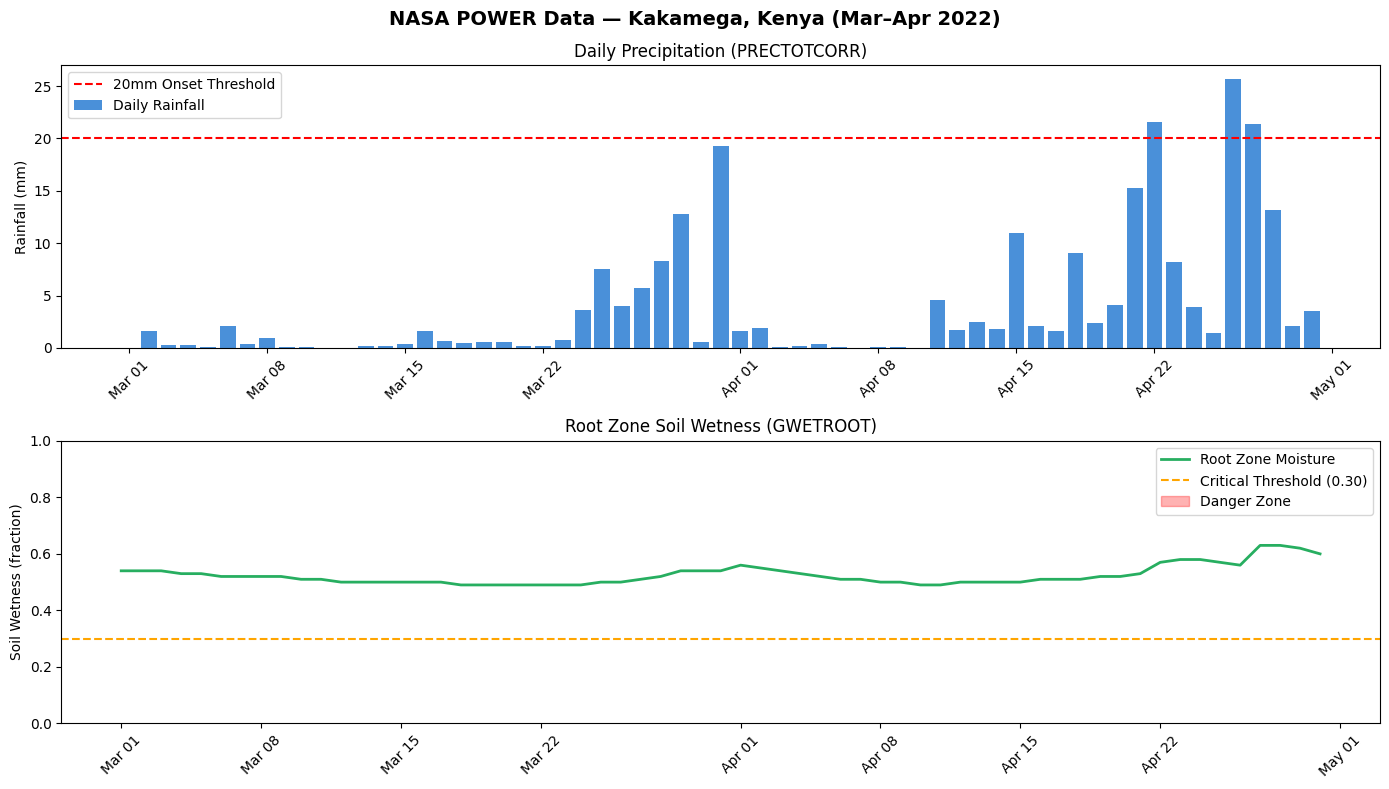

Chart saved!


In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle("NASA POWER Data — Kakamega, Kenya (Mar–Apr 2022)", 
             fontsize=14, fontweight='bold')

# --- Rainfall chart ---
ax1.bar(df.index, df["rainfall_mm"], 
        color="#4A90D9", width=0.8, label="Daily Rainfall")
ax1.axhline(y=20, color="red", linestyle="--", 
            linewidth=1.5, label="20mm Onset Threshold")
ax1.set_ylabel("Rainfall (mm)")
ax1.set_title("Daily Precipitation (PRECTOTCORR)")
ax1.legend()
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

# --- Soil moisture chart ---
ax2.plot(df.index, df["soil_moisture"], 
         color="#27AE60", linewidth=2, label="Root Zone Moisture")
ax2.axhline(y=0.30, color="orange", linestyle="--", 
            linewidth=1.5, label="Critical Threshold (0.30)")
ax2.fill_between(df.index, df["soil_moisture"], 0.30,
                 where=(df["soil_moisture"] < 0.30),
                 color="red", alpha=0.3, label="Danger Zone")
ax2.set_ylabel("Soil Wetness (fraction)")
ax2.set_ylim(0, 1)
ax2.set_title("Root Zone Soil Wetness (GWETROOT)")
ax2.legend()
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig("../data/kakamega_2022_exploration.png", 
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [11]:
# Save a summary of what we learned to the data folder
summary = {
    "location": "Kakamega, Kenya",
    "coordinates": {"lat": 0.28, "lon": 34.75},
    "period": "2022-03-01 to 2022-04-30",
    "findings": {
        "total_rainfall_mm": round(float(df["rainfall_mm"].sum()), 1),
        "max_single_day_mm": round(float(df["rainfall_mm"].max()), 1),
        "max_rain_date": str(df["rainfall_mm"].idxmax().date()),
        "avg_soil_moisture": round(float(df["soil_moisture"].mean()), 3),
        "days_below_critical_moisture": int((df["soil_moisture"] < 0.30).sum()),
        "days_above_onset_threshold": int((df["rainfall_mm"] >= 20).sum())
    }
}

import json
with open("../data/exploration_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))
print("\nSummary saved to data folder!")

{
  "location": "Kakamega, Kenya",
  "coordinates": {
    "lat": 0.28,
    "lon": 34.75
  },
  "period": "2022-03-01 to 2022-04-30",
  "findings": {
    "total_rainfall_mm": 234.3,
    "max_single_day_mm": 25.7,
    "max_rain_date": "2022-04-26",
    "avg_soil_moisture": 0.525,
    "days_below_critical_moisture": 0,
    "days_above_onset_threshold": 3
  }
}

Summary saved to data folder!
